Привет очередной раз, меня зовут Люман Аблаев. Сегодня я проверю твой проект.
<br> Дальнейшее общение будет происходить на "ты" если это не вызывает никаких проблем.
<br> Желательно реагировать на каждый мой комментарий ('исправил', 'не понятно как исправить ошибку', ...)
<br> Пожалуйста, не удаляй комментарии ревьюера, так как они повышают качество повторного ревью.

Комментарии будут в <font color='green'>зеленой</font>, <font color='blue'>синей</font> или <font color='red'>красной</font> рамках:

<div class="alert alert-block alert-success">
<b>Успех:</b> Если все сделано отлично
</div>

<div class="alert alert-block alert-info">
<b>Совет: </b> Если можно немного улучшить
</div>

<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Если требуются исправления. Работа не может быть принята с красными комментариями.
</div>

-------------------

Будет очень хорошо, если ты будешь помечать свои действия следующим образом:
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> ..
</div>
<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения ...
</div>

<font color='orange' style='font-size:24px; font-weight:bold'>Полезные ссылки:</font>
* Полезная лекция про временные ряды: https://www.youtube.com/watch?v=u433nrxdf5k .

<font color='orange' style='font-size:24px; font-weight:bold'>Общее впечатление</font>
* Большое спасибо за проделанную работу. Видно, что приложено много усилий.
- Приятное оформление выводов и структурированность кода в целом!  Приятно проверять такие работы.
* Над этим проектом нужно будет еще немного поработать. Однако, изменения не должны занять много времени.
* В работе я оставил несколько советов. Буду рад, если ты учтешь их.
- Жду твой обновленный проект =)





<font color='orange' style='font-size:24px; font-weight:bold'>Общее впечатление[2]</font>
* Спасибо за оперативность
- Недочеты исправлены - работа полностью корректна
- Рад был быть полезен. Удачи в дальнейшем обучении!


<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span><ul class="toc-item"><li><span><a href="#График-временного-ряда,-скользящее-среднее,-скользящее-стандартное-отклонение" data-toc-modified-id="График-временного-ряда,-скользящее-среднее,-скользящее-стандартное-отклонение-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>График временного ряда, скользящее среднее, скользящее стандартное отклонение</a></span></li><li><span><a href="#Тренд,-сезонность,-остаточный-шум" data-toc-modified-id="Тренд,-сезонность,-остаточный-шум-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Тренд, сезонность, остаточный шум</a></span></li><li><span><a href="#Cезонность-заказов-в-течение-дня" data-toc-modified-id="Cезонность-заказов-в-течение-дня-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Cезонность заказов в течение дня</a></span></li><li><span><a href="#Автокорреляция" data-toc-modified-id="Автокорреляция-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Автокорреляция</a></span></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    TimeSeriesSplit,
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    RobustScaler,
    StandardScaler
)
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

try:
    from lightgbm import LGBMRegressor
except ImportError:
    import sys
    !{sys.executable} -m pip install lightgbm -q
    from lightgbm import LGBMRegressor

try:
    from catboost import CatBoostRegressor
except ImportError:
    import sys
    !{sys.executable} -m pip install catboost -q
    from catboost import CatBoostRegressor

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

In [30]:
RANDOM_STATE = 42


<div class="alert alert-block alert-success">
<b>Успех:</b> Импорты  как всегда на месте
</div>


## Подготовка

In [31]:
df_taxi = pd.read_csv('Проекты/Taxi/taxi.csv', parse_dates=[0], index_col=[0])

<div class="alert alert-block alert-success">
<b>Успех:</b> Отлично, что использолованы параметры index_col и parse_dates
</div>



In [32]:
print('Таблицa taxi:')
display(df_taxi.head())
df_taxi.info()

Таблицa taxi:


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [33]:
df_taxi.describe()

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


In [34]:
df_taxi_dub = df_taxi.reset_index().duplicated().sum()
print(f'Количество дубликатов: {df_taxi_dub}')

Количество дубликатов: 0


Данные загружены, столбец `datetime` приведен к типу `datetime64[ns]`, так же преведен в индекс при загрузке данных. Проведена сортировка по назначенному индексу.

+ данные разделены на 10 минутные преомежутки
+ есть периоды с количеством заказов 0 и с максимальным значением 119
+ пропуски отсутствуют
Для дальнейшей обработки необходимо увеличить интервалы до 1 часа.

## Анализ

In [35]:
df_taxi = df_taxi.resample('1H').sum()

df_taxi.head()
df_taxi.info()
df_taxi.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


</div>

<div class="alert alert-block alert-success">
<b>Успех:</b> Первичный осмотр проведен, ресемпилнг был сделан верно.
</div>



### График временного ряда, скользящее среднее, скользящее стандартное отклонение

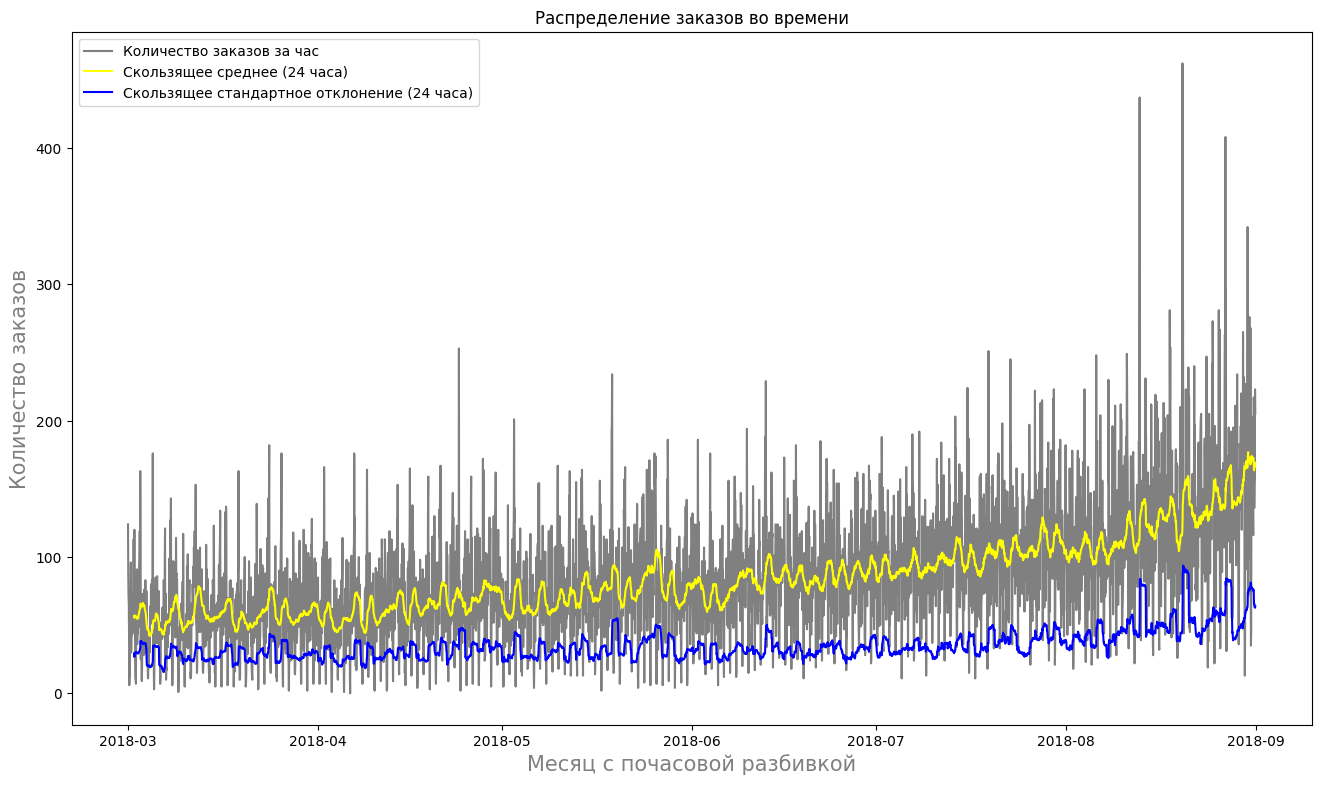

In [36]:
plt.figure(figsize=(16, 9))
plt.plot(df_taxi,color='grey')
plt.plot(df_taxi.shift().rolling(24).mean(),color='yellow')
plt.plot(df_taxi.shift().rolling(24).std(),color='blue')
plt.title('Распределение заказов во времени')
plt.xlabel("Месяц с почасовой разбивкой", fontsize=15, color='grey')
plt.ylabel("Количество заказов", fontsize=15, color='grey')
plt.legend(['Количество заказов за час', 'Скользящее среднее (24 часа)', 'Скользящее стандартное отклонение (24 часа)'])
plt.show();

### Тренд, сезонность, остаточный шум

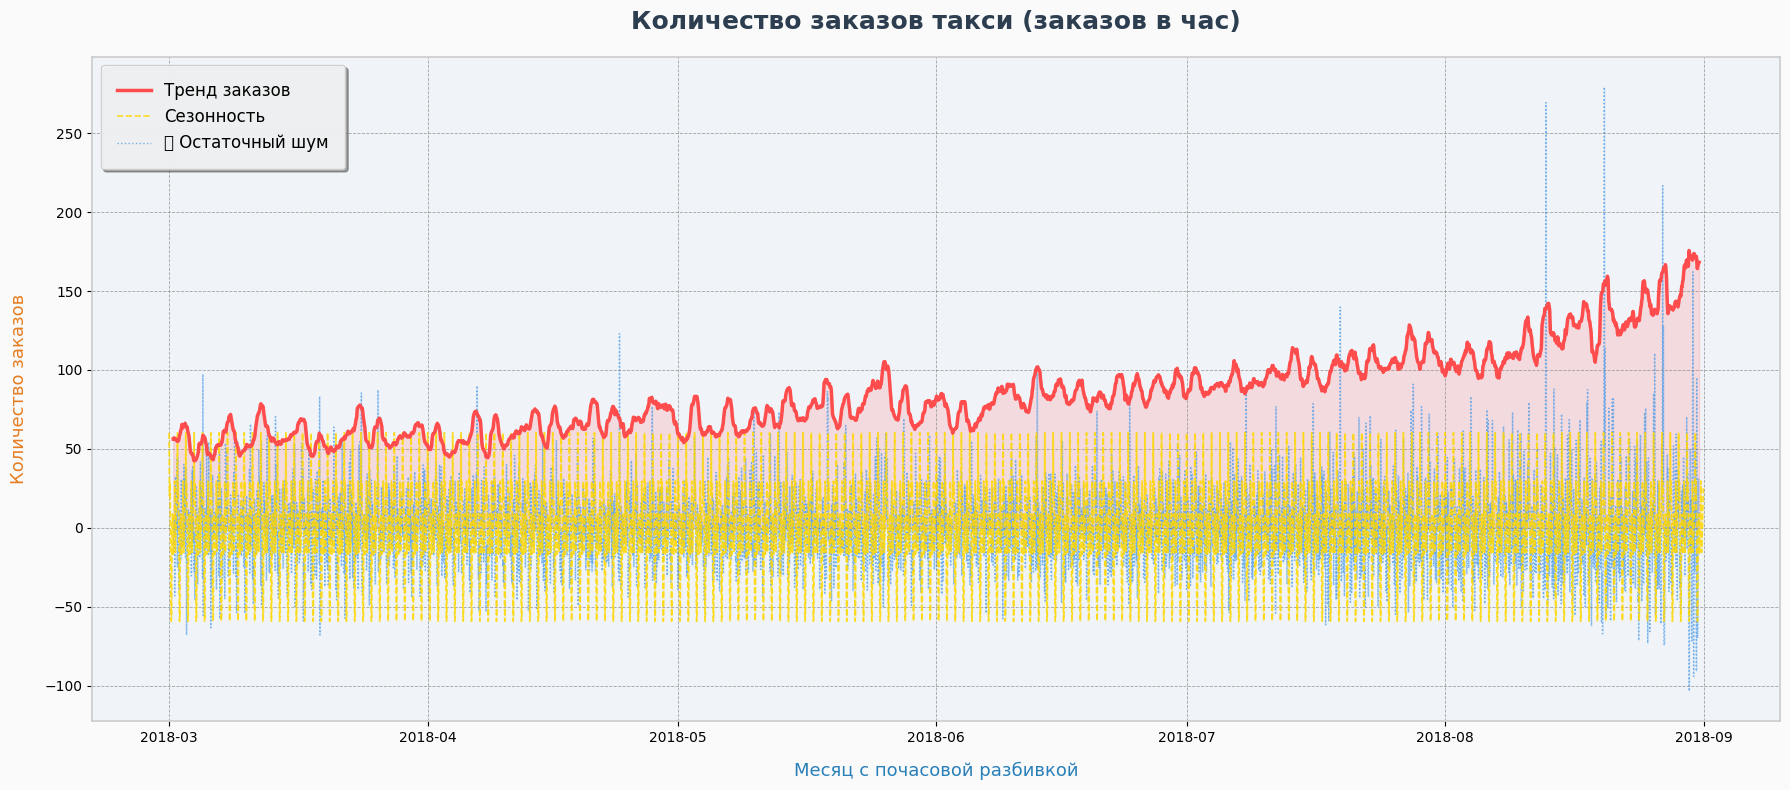

In [37]:
decomposed = seasonal_decompose(df_taxi)
# plt.style.use('seaborn-darkgrid')
fig, ax = plt.subplots(figsize=(18, 8))
ax.fill_between(decomposed.trend.index, decomposed.trend, alpha=0.15, color='#FF4C4C')
ax.fill_between(decomposed.seasonal.index, decomposed.seasonal, alpha=0.10, color='#FFD700')
ax.fill_between(decomposed.resid.index, decomposed.resid, alpha=0.10, color='#4C9BE8')
ax.plot(decomposed.trend, 
        color='#FF4C4C', linewidth=2.5, linestyle='-', 
        label='Тренд заказов', zorder=3)
ax.plot(decomposed.seasonal, 
        color='#FFD700', linewidth=1.2, linestyle='--', 
        alpha=0.85, label='Сезонность', zorder=2)
ax.plot(decomposed.resid, 
        color='#4C9BE8', linewidth=1.0, linestyle=':', 
        alpha=0.75, label='〰️ Остаточный шум', zorder=1)
ax.set_title('Количество заказов такси (заказов в час)', 
             fontsize=18, fontweight='bold', color='#2C3E50', pad=20)
ax.set_xlabel('Месяц с почасовой разбивкой', 
              fontsize=13, color='#2980B9', labelpad=12)
ax.set_ylabel('Количество заказов', 
              fontsize=13, color='#E67E22', labelpad=12)
ax.legend(
    fontsize=12,
    loc='upper left',
    frameon=True,
    framealpha=0.9,
    edgecolor='#CCCCCC',
    facecolor='#F8F9FA',
    shadow=True,
    borderpad=1.0
)
ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.7, color='gray')
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')
    spine.set_linewidth(1.2)
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#F0F4F8')

plt.tight_layout()
plt.show()

### Cезонность заказов в течение дня

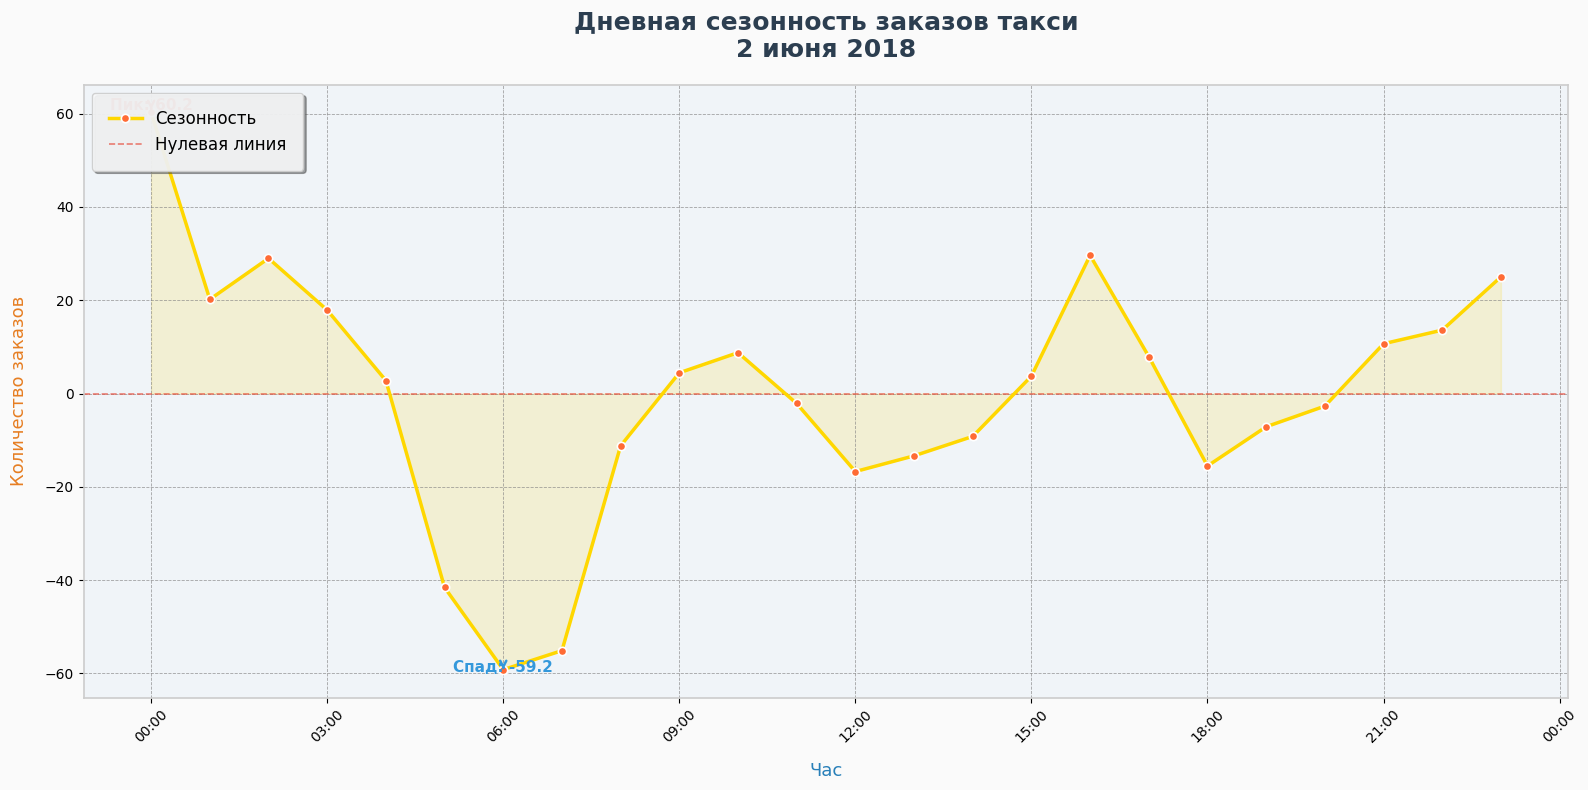

In [38]:
# plt.style.use('seaborn-darkgrid')

fig, ax = plt.subplots(figsize=(16, 8))

seasonal_day = decomposed.seasonal['2018-06-02':'2018-06-02']

ax.fill_between(seasonal_day.index, seasonal_day, 
                alpha=0.15, color='#FFD700')

ax.plot(seasonal_day,
        color='#FFD700', 
        linewidth=2.5, 
        linestyle='-',
        marker='o',          
        markersize=6,
        markerfacecolor='#FF6B35',
        markeredgecolor='white',
        markeredgewidth=1.2,
        label='Сезонность', 
        zorder=3)

ax.axhline(y=0, color='#E74C3C', linewidth=1.2, 
           linestyle='--', alpha=0.7, label='Нулевая линия')

ax.set_title('Дневная сезонность заказов такси\n2 июня 2018', 
             fontsize=18, fontweight='bold', 
             color='#2C3E50', pad=20)

ax.set_xlabel('Час', 
              fontsize=13, color='#2980B9', labelpad=12)

ax.set_ylabel('Количество заказов', 
              fontsize=13, color='#E67E22', labelpad=12)

ax.legend(
    fontsize=12,
    loc='upper left',
    frameon=True,
    framealpha=0.9,
    edgecolor='#CCCCCC',
    facecolor='#F8F9FA',
    shadow=True,
    borderpad=1.0
)

max_val = seasonal_day.max()
max_idx = seasonal_day.idxmax()

ax.annotate(f'Пик: {max_val:.1f}',
            xy=(max_idx, max_val),
            xytext=(max_idx, max_val + 0.5),
            fontsize=11,
            color='#E74C3C',
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', 
                           color='#E74C3C', 
                           lw=1.8),
            ha='center')

min_val = seasonal_day.min()
min_idx = seasonal_day.idxmin()

ax.annotate(f'Спад: {min_val:.1f}',
            xy=(min_idx, min_val),
            xytext=(min_idx, min_val - 0.5),
            fontsize=11,
            color='#3498DB',
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', 
                           color='#3498DB', 
                           lw=1.8),
            ha='center')

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%H:%M')
)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.7, color='gray')

for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')
    spine.set_linewidth(1.2)

fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#F0F4F8')

plt.tight_layout()
plt.show()

### Автокорреляция

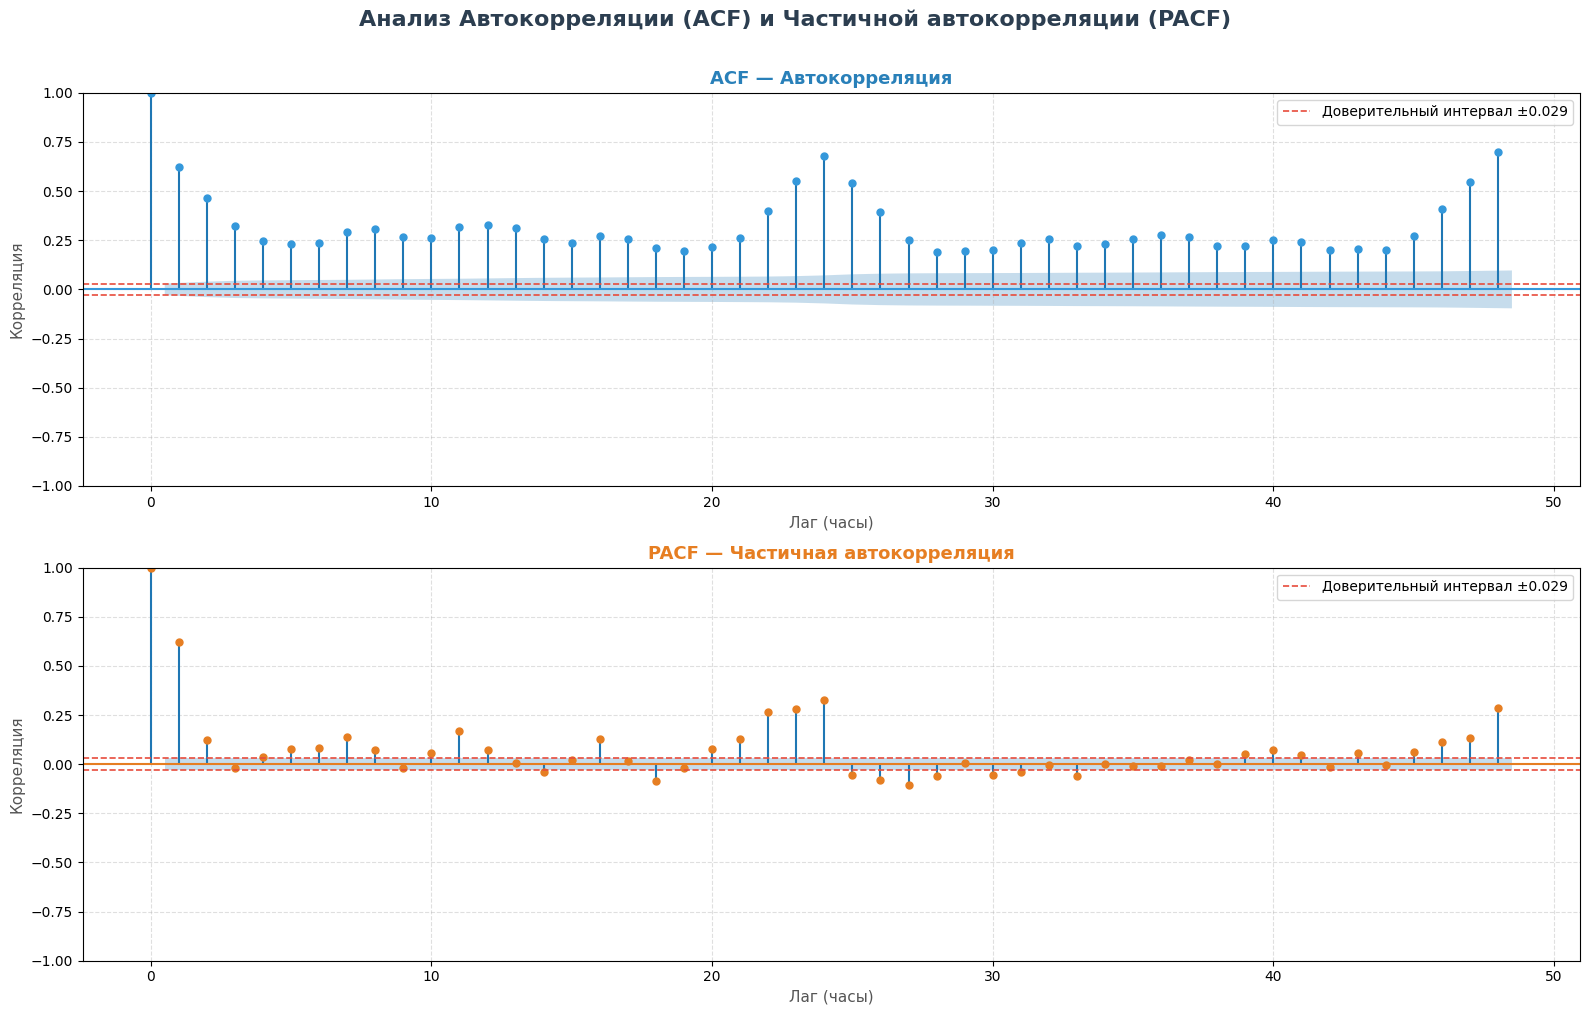

Доверительный интервал (95%): ±0.0295
Порог значимости:       0.1
Значимые лаги ACF  (48)  : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
Значимые лаги PACF (9): [1, 7, 11, 16, 22, 23, 24, 47, 48]
Итоговые значимые лаги (48): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]


In [39]:
def analyze_autocorrelation(data, col='num_orders', max_lag=48, threshold=0.1):
    """
    Анализ автокорреляции и частичной автокорреляции
    Возвращает значимые лаги
    
    threshold : минимальный порог значимости (по умолчанию 0.1)
    """
    series = data[col].dropna()
    
    # Вычисление ACF и PACF 
    acf_values  = acf(series,  nlags=max_lag, fft=True)
    pacf_values = pacf(series, nlags=max_lag, method='ywm')
    
    # Доверительный интервал (95%)
    confidence = 1.96 / np.sqrt(len(series))
    
    # Значимые лаги (превышают доверительный интервал + threshold)
    significant_acf  = [i for i in range(1, max_lag + 1)
                        if abs(acf_values[i])  > confidence + threshold]
    significant_pacf = [i for i in range(1, max_lag + 1)
                        if abs(pacf_values[i]) > confidence + threshold]
    
    # Визуализация
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Анализ Автокорреляции (ACF) и Частичной автокорреляции (PACF)',
                 fontsize=16, fontweight='bold', color='#2C3E50', y=1.01)
    
    plot_acf(series, lags=max_lag, ax=axes[0],
             color='#3498DB', title='')
    axes[0].set_title('ACF — Автокорреляция', 
                      fontsize=13, fontweight='bold', color='#2980B9')
    axes[0].set_xlabel('Лаг (часы)', fontsize=11, color='#555')
    axes[0].set_ylabel('Корреляция',  fontsize=11, color='#555')
    axes[0].axhline(y= confidence, color='#E74C3C', linestyle='--', 
                    linewidth=1.2, label=f'Доверительный интервал ±{confidence:.3f}')
    axes[0].axhline(y=-confidence, color='#E74C3C', linestyle='--', linewidth=1.2)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.4, linestyle='--')
    
    plot_pacf(series, lags=max_lag, ax=axes[1],
              color='#E67E22', title='', method='ywm')
    axes[1].set_title('PACF — Частичная автокорреляция', 
                      fontsize=13, fontweight='bold', color='#E67E22')
    axes[1].set_xlabel('Лаг (часы)', fontsize=11, color='#555')
    axes[1].set_ylabel('Корреляция',  fontsize=11, color='#555')
    axes[1].axhline(y= confidence, color='#E74C3C', linestyle='--', 
                    linewidth=1.2, label=f'Доверительный интервал ±{confidence:.3f}')
    axes[1].axhline(y=-confidence, color='#E74C3C', linestyle='--', linewidth=1.2)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.4, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # Отчёт
    print('='*55)
    print(f'Доверительный интервал (95%): ±{confidence:.4f}')
    print(f'Порог значимости:       {threshold}')
    print('='*55)
    print(f'Значимые лаги ACF  ({len(significant_acf)})  : {significant_acf}')
    print(f'Значимые лаги PACF ({len(significant_pacf)}): {significant_pacf}')
    print('='*55)
    
    # Объединяем уникальные значимые лаги из ACF и PACF
    significant_lags = sorted(set(significant_acf) | set(significant_pacf))
    print(f'Итоговые значимые лаги ({len(significant_lags)}): {significant_lags}')
    print('='*55)
    
    return significant_lags, acf_values, pacf_values


significant_lags, acf_vals, pacf_vals = analyze_autocorrelation(
    df_taxi, col='num_orders', max_lag=48, threshold=0.1
)

- Суточная сезонность  (лаг 24)  — повторение каждые 24 часа
- Двухсуточная         (лаг 48)  — подтверждает устойчивость цикла
- Инерция ряда         (лаг 1)   — сильная зависимость от предыдущего часа

In [40]:
data = df_taxi.copy()
data['hour'] = data.index.hour
data['week_day'] = data.index.dayofweek+1

max_lag = 24
for lag in range(1, max_lag + 1):
    data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

rolling_mean_size = 7
for rol in range(1, rolling_mean_size + 1):
    data['rol_{}'.format(rol)] = data['lag_1'].shift().rolling(rol).mean().round(2)

data = data.dropna()

data.head(5)

,num_orders,hour,week_day,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rol_1,rol_2,rol_3,rol_4,rol_5,rol_6,rol_7
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,90,0,5,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,113.0,89.5,80.00,71.25,71.6,67.00,63.57
2018-03-02 01:00:00,120,1,5,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,58.0,85.5,79.00,74.50,68.6,69.33,65.71
2018-03-02 02:00:00,75,2,5,120.0,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,90.0,74.0,87.00,81.75,77.6,72.17,72.29
2018-03-02 03:00:00,64,3,5,75.0,120.0,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,120.0,105.0,89.33,95.25,89.4,84.67,79.00
2018-03-02 04:00:00,20,4,5,64.0,75.0,120.0,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,75.0,97.5,95.00,85.75,91.2,87.00,83.29


<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Наши календарные признаки подчеркивают сезонность. Относительно сезонности признаки идут на один уровень ниже. Если у нас суточная сезонность, то логично создавать признак часа (час одного дня похож на тот же час другого), если недельная - день недели.
    
Поэтому не хватает признака - дня недели.
    

А с остальными вроде все отлично


</div>     

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения: добавлен признак week_day
</div>


<div class="alert alert-block alert-success">
    
<b>Успех[2]:</b> 👍 Есть контакт
</div>




<div class="alert alert-block alert-info">
<b>Совет:</b> пару строк про lag и скользящее среднее
    
Lag: его называют ещё параметром авторегрессии.<br>Допустим lag=1 - учитывает (для удобства будем считать, что продажи собраны по дням) как вчерашние продажи - вчерашние события - влияют на сегодняшние.<br>Lag=2: учитывает как позавчерашние продажи влияютна сегодняшние.....<br><br><br>
    
По скользящему среднего:<br>
Предположим rolling=10 - скользящее среднее. По сути, ищем среднее по 10 точкам, потом следующие 10 точек, и т.д. - это некое подобие тренда будет - средней линии. Т.е. - сглаживание колебаний/выбросов. Это легко увидеть на пределе: допустим длина ряда 100 дней. rolling(100) - это просто одно число - среднее всего ряда. <br><br><br>
    
    
    
**Обычно так происходит поиск параметров:**

1) узнаём , какая у нас сезонность: в нашем случае их две - часовая и день недели (суточная и недельная)<br>
2) Узнайм, какой у нас тренд. пусть будет пока rolling (24) - сутки<br>
3) строим модель (без лагов).<br>
4) строим график автокорреляции остатков (факт - прогноз). Если видим "зубья" на сезонных лагах: 24, 24*7 - то мы плохо жанной моделью учли сезонность.<br>
Если высокий "зуб"(столбец на графике) на на первом лаге, то ндо вводить в модель фактор lag=1.
и перестроить модель. И так по кругу.<br><br>   
    
Поэтому, если выставить сезонности - час и день недели, то дополнительные факторы желательно начинать с таких значений : лаг =1,2 а скользящее среднее = 24 (среднее за сутки).  В итоге модель будет приемлемая по точности и не много факторов.. а это значит и для бизнеса будет легче доносить решение). Но, если нужно улучшить качество, то в нашем же случае лаг в 24 (день) и 168 (неделя) - тоже имеют смысл.
</div>


In [41]:
print(data.dtypes)

num_orders      int64
hour            int32
week_day        int32
lag_1         float64
lag_2         float64
lag_3         float64
lag_4         float64
lag_5         float64
lag_6         float64
lag_7         float64
lag_8         float64
lag_9         float64
lag_10        float64
lag_11        float64
lag_12        float64
lag_13        float64
lag_14        float64
lag_15        float64
lag_16        float64
lag_17        float64
lag_18        float64
lag_19        float64
lag_20        float64
lag_21        float64
lag_22        float64
lag_23        float64
lag_24        float64
rol_1         float64
rol_2         float64
rol_3         float64
rol_4         float64
rol_5         float64
rol_6         float64
rol_7         float64
dtype: object


In [42]:
data['hour']= data['hour'].astype('category')
data['week_day']= data['week_day'].astype('category')

▌ Вывод по итогам анализа данных

- В течение анализируемого периода наблюдается устойчивый рост скользящего среднего, что указывает на увеличение числа перелётов и, как следствие, количества заказов такси.
- В данных прослеживается выраженная суточная сезонность: пики заказов приходятся примерно на 10:00, 16:00 и 00:00. Это может быть связано с тем, что пассажиры чаще всего совершают перелёты утром или вечером, либо с особенностями расписания рейсов в рассматриваемом городе. Минимальное количество вызовов такси отмечается в 6 утра. Неравномерность распределения заказов также объясняется графиком прилётов и вылетов самолётов.
- Динамика заказов такси демонстрирует рост с минимума во вторник до максимума к пятнице, после чего в выходные и понедельник наблюдается спад.

<div class="alert alert-block alert-success">
  
<b>Успех:</b> Проведен детальный анализ временного ряда, с наблюдениями согласен

По «остаткам» или шуму. Можно посмотреть, на всем ли протяжении доля остатков одинаковая? Если если «остатков» к концу графика больше, значит в тестовую выборку попадет чуть больше данных, которые сложно объяснить и на которых модели будет сложнее предсказывать. Поэтому относительно большая (по сравнению с другими задачами машинного обучения) разница между метриками при обучении и исследовании, и между тестовой выборкой, не обязательно будет объясняться только переобучением модели.

           
</div>

<div class="alert alert-block alert-info">
    
<b>Совет:</b> Дополнительно  полезно оценивать стационарность ряда с помощью теста Дики-Фуллера: в реальных задачах с временными рядами, в особенности - с финансовыми данными или биржевыми котировками, график не всегда поможет достоверно оценить стационарность ряда, поэтому для оценки стационарности ряда лучше использовать тест Дики — Фуллера (подробнее о нём можно глянуть тут: https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html, а вот тут можно глянуть пример реализации:  https://habr.com/ru/articles/540868/) - он даст наиболее точный результат. Результат нужно проверить на уровнях значимости 1% и 5%, чтобы быть уверенным в выводах. Не забудь при применении теста сформулировать гипотезы - нулевая формулируется как гипотеза о нестацинарности ряда, а альтернативная - как гипотеза о стационарности ряда. Также при проведении теста не забывай, что мы сравниваем `p-value` с уровнем значимости `alpha`.
</div>





## Обучение

In [43]:
tscv = TimeSeriesSplit()



<div class="alert alert-block alert-success">
<b>Успех:</b> Лайк за TimeSeriesSplit - это важно для временных рядов при работе с кросс-валидацией</div>


In [44]:
X = data.drop(columns=['num_orders'])
y = data['num_orders']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1, shuffle=False)
print(f'Диапазон дат в обучающей выбоке: {X_train.index.min()} - {X_train.index.max()}')
print(f'Диапазон дат в тестовой выбоке: {X_test.index.min()} - {X_test.index.max()}')
print(f'Соотношение объема выборок {round((X_train.shape[0] / X.shape[0]), 2)}:{round((X_test.shape[0] / X.shape[0]), 2)}')

Диапазон дат в обучающей выбоке: 2018-03-02 00:00:00 - 2018-08-13 15:00:00
Диапазон дат в тестовой выбоке: 2018-08-13 16:00:00 - 2018-08-31 23:00:00
Соотношение объема выборок 0.9:0.1


In [45]:
X = data.drop(columns=['num_orders'])
y = data['num_orders']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.1, 
    shuffle=False
)

cat_col = X_train.select_dtypes(include=['category']).columns.tolist()
num_col = X_train.select_dtypes(include=['int', 'float']).columns.tolist()

print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')
print(f'Категориальные признаки ({len(cat_col)}): {cat_col}')
print(f'Числовые признаки ({len(num_col)}): {num_col}')



Размер обучающей выборки: (3952, 33)
Размер тестовой выборки: (440, 33)
Категориальные признаки (2): ['hour', 'week_day']
Числовые признаки (31): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'rol_1', 'rol_2', 'rol_3', 'rol_4', 'rol_5', 'rol_6', 'rol_7']


In [46]:
ohe_pipe = Pipeline([
    ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='error'))
])

data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, cat_col),
    ('num', StandardScaler(), num_col)
], remainder='passthrough')

models_params = {
    'DecisionTreeRegressor': {
        'model': DecisionTreeRegressor(random_state=RANDOM_STATE),
        'use_preprocessor': True,
        'params': {
            'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
            'models__max_depth': [None] + list(range(2, 7)),
            'models__max_features': list(range(2, 15))
        }
    },
    'Ridge': {
        'model': Ridge(random_state=RANDOM_STATE),
        'use_preprocessor': True,
        'params': {
            'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
            'models__alpha': (0.001, 0.01, 0.1, 1, 10, 100, 1000),
            'models__fit_intercept': (True, False),
            'models__solver': ('auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga')
        }
    },
    'LGBMRegressor': {
        'model': LGBMRegressor(verbose=-1, random_state=RANDOM_STATE),
        'use_preprocessor': False,
        'params': {
            'models__n_estimators': [150, 200],
            'models__max_depth': [None] + list(range(2, 7))
        }
    },
    'CatBoostRegressor': {
        'model': CatBoostRegressor(random_state=RANDOM_STATE, cat_features=cat_col, verbose=False),
        'use_preprocessor': False,
        'params': {
            'models__depth': (5, 6, 7),
            'models__iterations': list(range(170, 190, 5)),
            'models__learning_rate': (0.01, 0.05, 0.1)
        }
    }
}

results = []

for model_name, config in models_params.items():
    print(f'Обучение модели: {model_name}')

    if config['use_preprocessor']:
        pipe = Pipeline([
            ('preprocessor', data_preprocessor),
            ('models', config['model'])
        ])
    else:
        pipe = Pipeline([
            ('models', config['model'])
        ])

    if model_name == 'CatBoostRegressor':
        grid = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=config['params'],
            n_iter=50,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    else:
        grid = GridSearchCV(
            estimator=pipe,
            param_grid=config['params'],
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )

    grid.fit(X_train, y_train)

    rmse = abs(grid.best_score_)
    
    results.append({
        'Model': model_name,
        'RMSE_CV': rmse,
        'Best_params': grid.best_params_,
        'Best_estimator': grid.best_estimator_
    })
    
    print(f'RMSE на кросс-валидации: {rmse:.3f}')
    print(f'Лучшие параметры: {grid.best_params_}\n')

Обучение модели: DecisionTreeRegressor
RMSE на кросс-валидации: 30.453
Лучшие параметры: {'models__max_depth': 6, 'models__max_features': 13, 'preprocessor__num': StandardScaler()}

Обучение модели: Ridge


/Users/artem/Desktop/Яндекс Практикум/yandex_p_pro/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artem/Desktop/Яндекс Практикум/yandex_p_pro/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artem/Desktop/Яндекс Практикум/yandex_p_pro/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artem/Desktop/Яндекс Практикум/yandex_p_pro/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artem/Desktop/Яндекс Практикум/yandex_p_pro/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_ite

RMSE на кросс-валидации: 25.371
Лучшие параметры: {'models__alpha': 0.1, 'models__fit_intercept': False, 'models__solver': 'sparse_cg', 'preprocessor__num': MinMaxScaler()}

Обучение модели: LGBMRegressor
RMSE на кросс-валидации: 24.244
Лучшие параметры: {'models__max_depth': 4, 'models__n_estimators': 150}

Обучение модели: CatBoostRegressor


RuntimeError: Cannot clone object CatBoostRegressor(cat_features=['hour', 'week_day'], loss_function='RMSE', random_state=42, verbose=False), as the constructor either does not set or modifies parameter cat_features

In [47]:
results_df = pd.DataFrame(results)[['Model', 'RMSE_CV', 'Best_params']]
results_df = results_df.sort_values('RMSE_CV').reset_index(drop=True)

best_model_info = min(results, key=lambda x: x['RMSE_CV'])
best_model = best_model_info['Best_estimator']
best_model_name = best_model_info['Model']

print(f'Лучшая модель: {best_model_name}')
print(f'RMSE: {best_model_info["RMSE_CV"]:.3f}')
print('\nРезультаты всех моделей:')
print(results_df.to_string(index=False))

Лучшая модель: LGBMRegressor
RMSE: 24.244

Результаты всех моделей:
                Model   RMSE_CV                                                                                                                Best_params
        LGBMRegressor 24.243692                                                                      {'models__max_depth': 4, 'models__n_estimators': 150}
                Ridge 25.371031 {'models__alpha': 0.1, 'models__fit_intercept': False, 'models__solver': 'sparse_cg', 'preprocessor__num': MinMaxScaler()}
DecisionTreeRegressor 30.453108                                {'models__max_depth': 6, 'models__max_features': 13, 'preprocessor__num': StandardScaler()}



<div class="alert alert-block alert-success">
<b>Успех:</b> Лаконичная работа с моделями
</div>


## Тестирование

In [48]:
y_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Лучшая модель: {best_model_name}')
print(f'Метрика RMSE на тестовой выборке: {rmse_test:.3f}')


Лучшая модель: LGBMRegressor
Метрика RMSE на тестовой выборке: 39.303



<div class="alert alert-block alert-success">
<b>Успех:</b> На тесте получено хорошее качество
</div>


<div class="alert alert-info">
<b>Совет:</b>

Здесь также было бы очень полезно визуализировать предсказания твоей лучшей модели и сравнить их с правильными ответами в формате линейного графика - так мы сможем более наглядно понять, в каких местах твоя модель делает хорошие предсказания, а в каких ошибается.
        
По графику обязательно нужно сделать вывод: стоит отметить, в каких участках ряда модель сильнее ошибается, а какие участки ряда предсказывает хорошо.

</div>


<div class="alert alert-block alert-danger">

<b>Ошибка:</b> Итоговый вывод?


# Вывод

1. Контекст и цель

Для построения модели прогнозирования использовались исторические данные по заказам такси в аэропортах за период с 01.03.2018 по 31.08.2018. Исходные данные фиксировали количество заказов с интервалом в 10 минут. Целью работы является прогнозирование числа заказов на следующий час для эффективного привлечения водителей в часы пиковой нагрузки.

2. Предобработка и исследовательский анализ

Форматирование данных: Выполнена сортировка по временному признаку и передискретизация (ресемплинг) данных с шагом в 1 час.

Анализ трендов и сезонности:

- Проведен визуальный анализ графиков исходных заказов, скользящего среднего (окно 24 часа) и скользящего стандартного отклонения, а также графиков тренда и остаточной компоненты.

- Тренд: Наблюдается устойчивый рост скользящего среднего к концу рассматриваемого периода, что свидетельствует об увеличении объема авиаперевозок и, как следствие, спроса на такси.

- Внутрисуточная сезонность: Выявлена ярко выраженная суточная цикличность. Пики заказов приходятся на 10:00, 16:00 и 00:00. Это может объясняться предпочтением пассажиров выбирать утренние и вечерние рейсы либо особенностями расписания аэропорта в данном городе. Минимальное число вызовов такси фиксируется в 6:00.

- Недельная динамика: Прослеживается циклическая волна: спрос растет со вторника по пятницу (начиная с минимальных значений во вторник), после чего снижается в субботу, воскресенье и понедельник.

3. Подготовка признаков

Сформированы следующие группы признаков:

- Категориальные: час суток, день недели.

- Числовые: сдвиг (лаг) количества заказов, а также скользящие средние значения.

4. Формирование выборок

Разделение данных: Исходные данные разделены на обучающую и тестовую выборки в пропорции 90% и 10% соответственно с сохранением хронологической последовательности.

Очистка: Из обучающей выборки удалены пропуски, образовавшиеся в ходе конструирования новых признаков.

5. Моделирование и оценка качества

В ходе обучения проводилась настройка гиперпараметров для следующих алгоритмов:

- DecisionTreeRegressor (Дерево решений)

- Ridge (Гребневая регрессия)

- LGBMRegressor (LightGBM)

- CatBoostRegressor (CatBoost)

Выбор лучшего решения: Оптимальной признана модель LGBMRegressor, показавшая наименьшее значение среднеквадратичной ошибки (RMSE) на валидационной выборке.

Проверка качества: Итоговое значение RMSE на тестовой выборке не превысило установленный порог в 48 единиц.


<div class="alert alert-block alert-info">
<b>Совет[2]:</b> Старайся выделять ключевые моменты в выводе (жирным шрифтом, подчеркивание и т.п.), такую информацию будет легче и приятнее воспринимать.


</div>



## Чек-лист проверки

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Данные загружены и подготовлены
- [x]  Данные проанализированы
- [x]  Модель обучена, гиперпараметры подобраны
- [x]  Качество моделей проверено, выводы сделаны
- [x]  Значение *RMSE* на тестовой выборке не больше 48